In [61]:
from urllib.request import urlopen
import json
import pandas as pd
import ssl
import datetime

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Загрузка данных

In [62]:
context = ssl._create_unverified_context()

In [63]:
response = urlopen("https://iss.moex.com/iss/engines/stock/markets/shares/boards/TQBR/securities.json", context=context)
json_data = response.read().decode('utf-8', 'replace')

d = json.loads(json_data)
securities = pd.DataFrame(columns=d["securities"]["columns"])

for i in range(len(d["securities"]["data"])):
    securities.loc[i] = d["securities"]["data"][i]

securities.set_index("SECID", inplace=True)
    
securities

,BOARDID,SHORTNAME,PREVPRICE,LOTSIZE,FACEVALUE,STATUS,BOARDNAME,DECIMALS,SECNAME,REMARKS,...,PREVDATE,ISSUESIZE,ISIN,LATNAME,REGNUMBER,PREVLEGALCLOSEPRICE,CURRENCYID,SECTYPE,LISTLEVEL,SETTLEDATE
SECID,,,,,,,,,,,,,,,,,,,,,
ABIO,TQBR,iАРТГЕН ао,80.520,10,0.10,A,Т+: Акции и ДР - безадрес.,2,"ПАО ""Артген""",None,...,2025-05-02,92645451,RU000A0JNAB6,ARTGEN ao,1-01-08902-A,80.72,SUR,1,2,2025-05-06
ABRD,TQBR,АбрауДюрсо,180.000,10,1.00,A,Т+: Акции и ДР - безадрес.,1,Абрау-Дюрсо ПАО ао,None,...,2025-05-02,98000184,RU000A0JS5T7,Abrau-Durso ao,1-02-12500-A,180.00,SUR,1,3,2025-05-06
AFKS,TQBR,Система ао,14.345,100,0.09,A,Т+: Акции и ДР - безадрес.,3,"АФК ""Система"" ПАО ао",None,...,2025-05-02,9650000000,RU000A0DQZE3,AFK Sistema,1-05-01669-A,14.46,SUR,1,1,2025-05-06
AFLT,TQBR,Аэрофлот,67.220,10,1.00,A,Т+: Акции и ДР - безадрес.,2,Аэрофлот-росс.авиалин(ПАО)ао,None,...,2025-05-02,3975771215,RU0009062285,Aeroflot,1-01-00010-A,68.13,SUR,1,1,2025-05-06
AGRO,TQBR,AGRO-гдр,1083.800,1,0.00,N,Т+: Акции и ДР - безадрес.,1,ГДР ROS AGRO PLC ORD SHS,None,...,2025-05-02,0,US7496552057,GDR ROS AGRO PLC ORD SHS,None,1085.20,SUR,D,3,2025-05-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
YRSB,TQBR,ТНСэнЯр,706.000,10,1.00,A,Т+: Акции и ДР - безадрес.,0,ТНС энерго Ярославль ПАО ао,None,...,2025-05-02,17143584,RU000A0D8760,TNS energo Yaroslavl' ao,1-01-50099-A,706.00,SUR,1,3,2025-05-06
YRSBP,TQBR,ТНСэнЯр-п,183.500,10,1.00,A,Т+: Акции и ДР - безадрес.,1,ТНС энерго Ярославль ПАО ап,None,...,2025-05-02,4507320,RU000A0D88B3,TNS energo Yaroslavl' (pref),2-01-50099-A,183.50,SUR,2,3,2025-05-06
ZAYM,TQBR,Займер ао,142.900,10,0.10,A,Т+: Акции и ДР - безадрес.,2,Займер ао,None,...,2025-05-02,100000000,RU000A107RM8,Zaymer,1-01-16767-A,143.10,SUR,1,3,2025-05-06


In [64]:
dividends = {}
excluded = []
for sec in securities.index:
    
    #загружаем историю дивидедов компании
    response = urlopen("https://iss.moex.com/iss/securities/" + sec + "/dividends.json", context=context)
    json_data = response.read().decode('utf-8', 'replace')
    div_data = json.loads(json_data)
    divs = []
    for div in div_data["dividends"]["data"]:
        
        # Исключаем компании выплачивающие дивиденды не в рублях
        if div[4] != "RUB":
            print("Компания " + sec + " выплачивала дивиденты в " + div[4])
            excluded += [sec]
            break
        
        #загружаем цены акций в день выплаты дивидедов
        date = datetime.datetime.strptime(div[2], "%Y-%m-%d")
        
        # Если дивиднды указыны более чем на год в будущем, возможно это ошибка, отсекаем такие данные
        if date > datetime.datetime.today() + datetime.timedelta(days=365):
            print("Компания " + sec + " дата выплаты далеко в будущем " + div[2])
            continue
        
        # ищем ближайший день с ценой, за который есть данные
        for day_shift in range(0,-10, -1):
            
            #Если дата в будущем, то ищем цену начиная от сегодняшнего дня 
            if date > datetime.datetime.today():
                date_t = datetime.datetime.today()
            else:
                date_t = date
            date_t += datetime.timedelta(days=day_shift)
            
            #запрос на получение цены за указанную дату
            response = urlopen("https://iss.moex.com/iss/securities/" + sec + "/aggregates.json?date=" + date_t.strftime('%Y-%m-%d'), context=context)
            json_data = response.read().decode('utf-8', 'replace')
            price_data = json.loads(json_data)
            
            # ищем информацию о цене (shares) в полученном массиве
            for price in price_data["aggregates"]["data"]:
                if price[0] == "shares" and price[5] > 0 and price[6] > 0:
                    
                    #если предыдущие дивиденты выплачивались меньше двух месяцев назад, прибавляем их к предыдущей выплате
                    if len(divs) > 0 and divs[len(divs)-1]["registryclosedate"] + datetime.timedelta(days=60) > date:
                        divs[len(divs)-1]["value"] += div[3]
                    else:
                        divs += [{"registryclosedate":date, "value":div[3], "price": price[5]/price[6] }]
                    break
            else:
                continue
            break
        else:    
            print("Компания " + sec + " не найдена цена за " + div[2])
    
    if(len(divs) > 1):
        dividends[sec] = sorted( divs, key=lambda div: div["registryclosedate"])
    else:
        excluded += [sec]

print("")
print("Исключенные из анализа компании:")
print(",".join(str(element) for element in excluded))

Компания GAZC не найдена цена за 2013-10-21
Компания GAZS не найдена цена за 2013-10-21
Компания KAZTP не найдена цена за 2013-08-02
Компания MOEX дата выплаты далеко в будущем 2111-01-01
Компания QIWI выплачивала дивиденты в USD

Исключенные из анализа компании:
ABIO,ABRD,AGRO,AMEZ,APRI,APTK,AQUA,ARSA,ASSB,ASTR,AVAN,BELU,BISVP,BLNG,BRZL,BSPB,BSPBP,CARM,CBOM,CHGZ,CHKZ,CHMK,CNRU,CNTL,CNTLP,DATA,DELI,DIAS,DIOD,DVEC,DZRD,DZRDP,EELT,ELFV,ELMT,ENPG,ETLN,EUTR,FESH,FIXP,FLOT,GAZA,GAZAP,GAZC,GAZS,GAZT,GCHE,GECO,GEMA,GEMC,GTRK,HEAD,HIMCP,HNFG,IGST,IGSTP,INGR,IRKT,IVAT,JNOS,JNOSP,KAZTP,KBSB,KCHE,KCHEP,KGKC,KGKCP,KLSB,KLVZ,KMAZ,KMEZ,KOGK,KRKN,KRKNP,KRKOP,KROT,KROTP,KRSB,KRSBP,KUZB,KZOS,KZOSP,LEAS,LENT,LIFE,LMBZ,LNZL,LNZLP,LPSB,LSNG,LSNGP,LVHK,MAGE,MAGEP,MBNK,MDMG,MFGS,MFGSP,MGKL,MGNZ,MGTS,MGTSP,MISB,MISBP,MRKC,MRKK,MRKP,MRKS,MRKU,MRKV,MRKY,MRKZ,MRSB,MTLR,NAUK,NFAZ,NKHP,NKNC,NKNCP,NKSH,NNSB,NNSBP,NSVZ,OGKB,OKEY,OMZZP,OZON,OZPH,PAZA,PMSB,PMSBP,POSI,PRFN,PRMB,PRMD,QIWI,QIWI,RAGR,RASP,RBCM,RDRB,RENI,

In [65]:
print("Компании выплачивавшие дивиденды более одного раза в рублях: " + str(len(dividends.keys()))  )

Компании выплачивавшие дивиденды более одного раза в рублях: 47


# Обработка данных

In [78]:
# количество последних лет, за которые будет произведен анализ
years_limit = 5

In [79]:
#отсекаем компании не платившие дивиденты больше года, или платившие первый раз менее двух лет назад
dividends2 = {}
excluded = []
for key in dividends.keys():
    first_date = dividends[key][0]["registryclosedate"]
    last_date = dividends[key][len(dividends[key]) -1]["registryclosedate"]
    if first_date + datetime.timedelta(days=365*years_limit) <= last_date and last_date + datetime.timedelta(days=365) >=  datetime.datetime.today():
        dividends2[key] = { "data": dividends[key], "average": 0, "x":[], "y":[], "label": key }
    else:
        excluded += [key]
print("Исключенные из анализа компании:")
print(",".join(str(element) for element in excluded))

Исключенные из анализа компании:
AFLT,AKRN,BANE,BANEP,FEES,GAZP,GMKN,HYDR,KAZT,LSRG,MSNG,MSRS,MSTT,MTLRP,MVID,NMTP,PIKK,SIBN,TGKA,UPRO,VSMO


In [80]:
print("Компании, платившие дивиденты не менее года назад и платящие более трех лет: " + str(len(dividends2.keys()))  )
print(",".join(str(element) for element in dividends2))

Компании, платившие дивиденты не менее года назад и платящие более трех лет: 26
AFKS,ALRS,CHMF,IRAO,LKOH,MAGN,MGNT,MOEX,MTSS,NLMK,NVTK,PHOR,PLZL,ROSN,RTKM,RTKMP,SBER,SBERP,SFIN,SNGS,SNGSP,TATN,TATNP,TRMK,TRNFP,VTBR


In [81]:
# строим серии графиков
for key in dividends2.keys():
    divs = dividends2[key]
    sum_value = 0
    sum_days = 0
    divs["x"] = []
    divs["y"] = []
    
    #print("")
    #print(key)
    data = divs["data"]
    for div_id in range(1, len(data)):
        date = data[div_id]["registryclosedate"]
        
        #отбираем данные за последние три года
        if date + datetime.timedelta(days=365*years_limit) < datetime.datetime.today():
            continue
        
        #определяем количество дней с последней выплаты дивидендов
        days = (date - data[div_id-1]["registryclosedate"]).days
        
        #print(date, days)
        
        #определяем среднее годовое значение дивидендов за дни после предыдущей выплаты
        value = (data[div_id]["value"] / data[div_id]["price"]) / ( days / 365 ) * 100
        
        
        divs["x"] += [date]
        divs["y"] += [value]
        
        sum_value += value * days
        sum_days += days
    
    divs["average"] = sum_value / sum_days


In [82]:
graphs = sorted(dividends2.values(), key=lambda div: div["average"], reverse=True)

# Визуализация

## Лучшие компании

In [83]:
dividends2.keys()

dict_keys(['AFKS', 'ALRS', 'CHMF', 'IRAO', 'LKOH', 'MAGN', 'MGNT', 'MOEX', 'MTSS', 'NLMK', 'NVTK', 'PHOR', 'PLZL', 'ROSN', 'RTKM', 'RTKMP', 'SBER', 'SBERP', 'SFIN', 'SNGS', 'SNGSP', 'TATN', 'TATNP', 'TRMK', 'TRNFP', 'VTBR'])

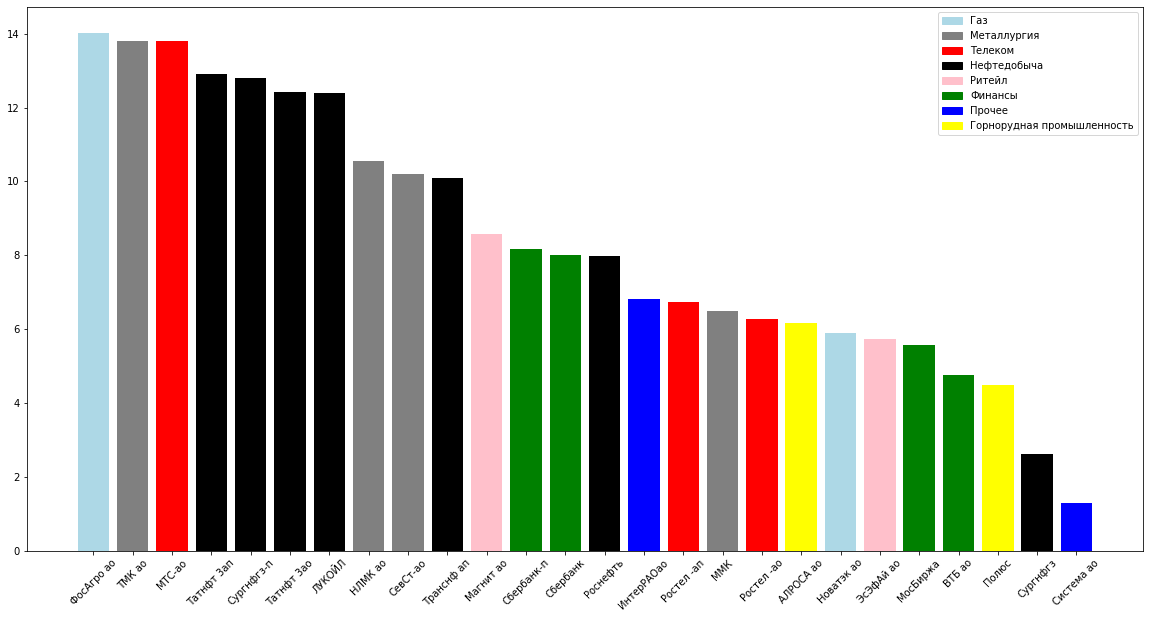

In [84]:
x = []
y = []
colors = []
legend = {}
for g in graphs:
    x += [ securities.loc[g["label"], "SHORTNAME"]]
    y += [g["average"]]
    
    #Нефтедобыча
    if g["label"] in ["TATN", "TATNP", "LKOH", "SNGSP", "SNGS", "TRNFP", "ROSN"]:
        color = "black"
        industry = "Нефтедобыча"
    
    #Газ
    elif g["label"] in ["NVTK", "PHOR"]:
        color = "lightblue" 
        industry = "Газ"
    
    #Горнорудная промышленность
    elif g["label"] in ["PLZL", "ALRS"]:
        color = "yellow"
        industry = "Горнорудная промышленность"
    
    #Ритейл
    elif g["label"] in ["MGNT", "SFIN"]:
        color = "pink"   
        industry = "Ритейл"
    
    #Металлургия
    elif g["label"] in ["TRMK", "NLMK", "CHMF", "MAGN"]:
        color = "grey"
        industry = "Металлургия"
    
    #Финансы
    elif g["label"] in ["SBERP", "SBER", "MOEX", "VTBR"]:
        color = "green"
        industry = "Финансы"
        
    #Телеком
    elif g["label"] in ["MTSS", "RTKMP", "RTKM"]:
        color = "red"
        industry = "Телеком"
    
    #Прочее
    else:
        color = "blue"
        industry = "Прочее"
        
    colors += [color]
    if industry not in legend.keys():
        legend[industry] = color

patchs = []
for key in legend.keys():
    patchs += [ mpatches.Patch(color=legend[key], label=key) ]

fig, ax = plt.subplots(figsize=(20,10))
ax.bar(x, y, color=colors)
ax.tick_params(axis='x', labelrotation=45)
ax.legend(handles=patchs)

## Графики выплат

In [85]:
def draw_graphs(gr, start, end):
    plt.figure(figsize=(20,20))
    legend = []
    for i in range(start,end):
        if i >= len(gr):
            break
            
        divs = gr[i]
        legend += [securities.loc[divs["label"], "SHORTNAME"] ]
        plt.plot(divs["x"], divs["y"])
    plt.legend(legend)

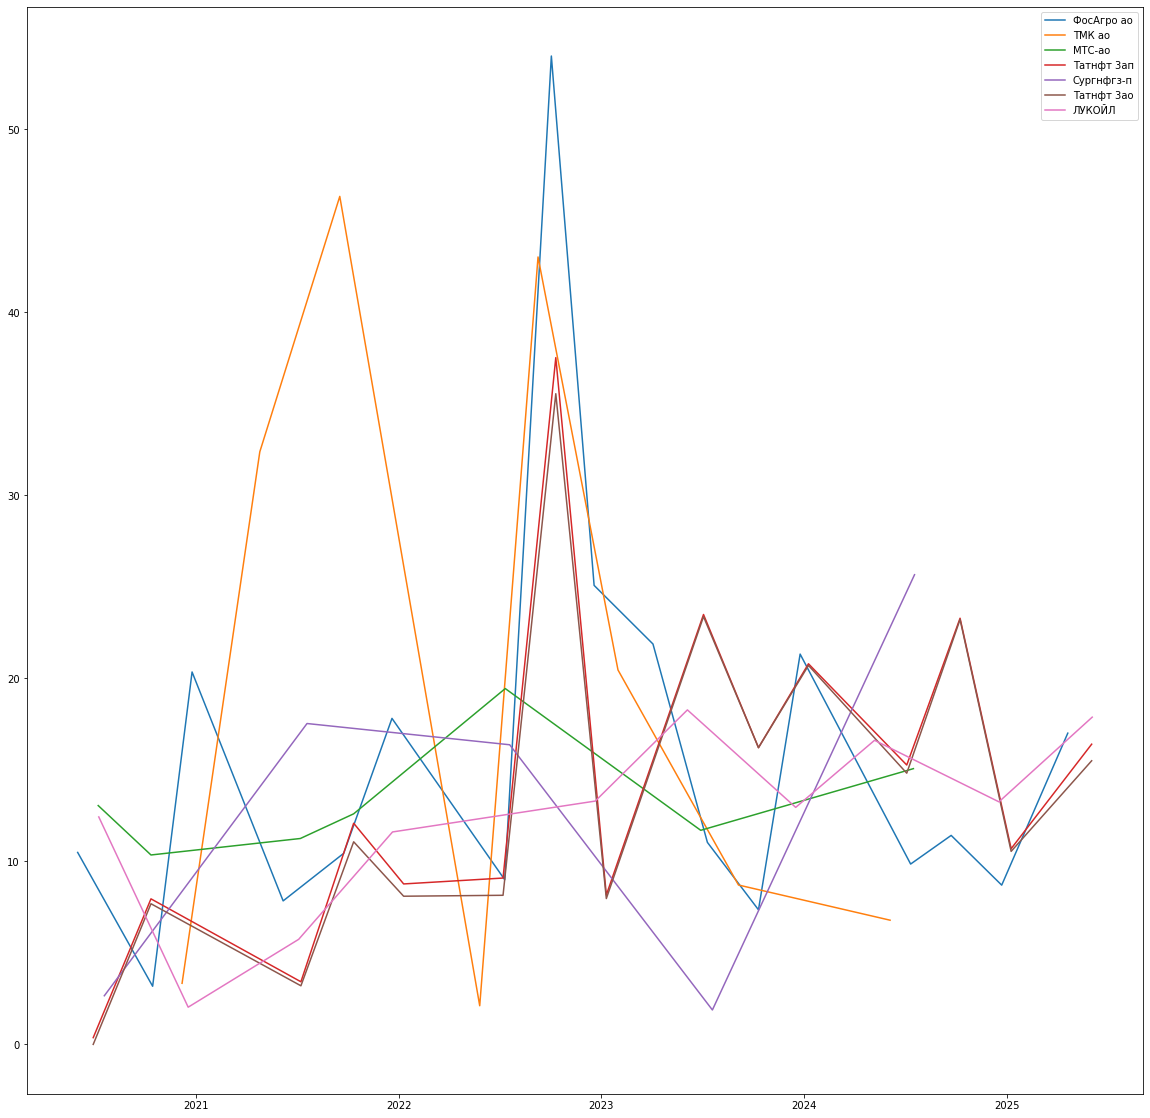

In [86]:
draw_graphs(graphs, 0, 7)

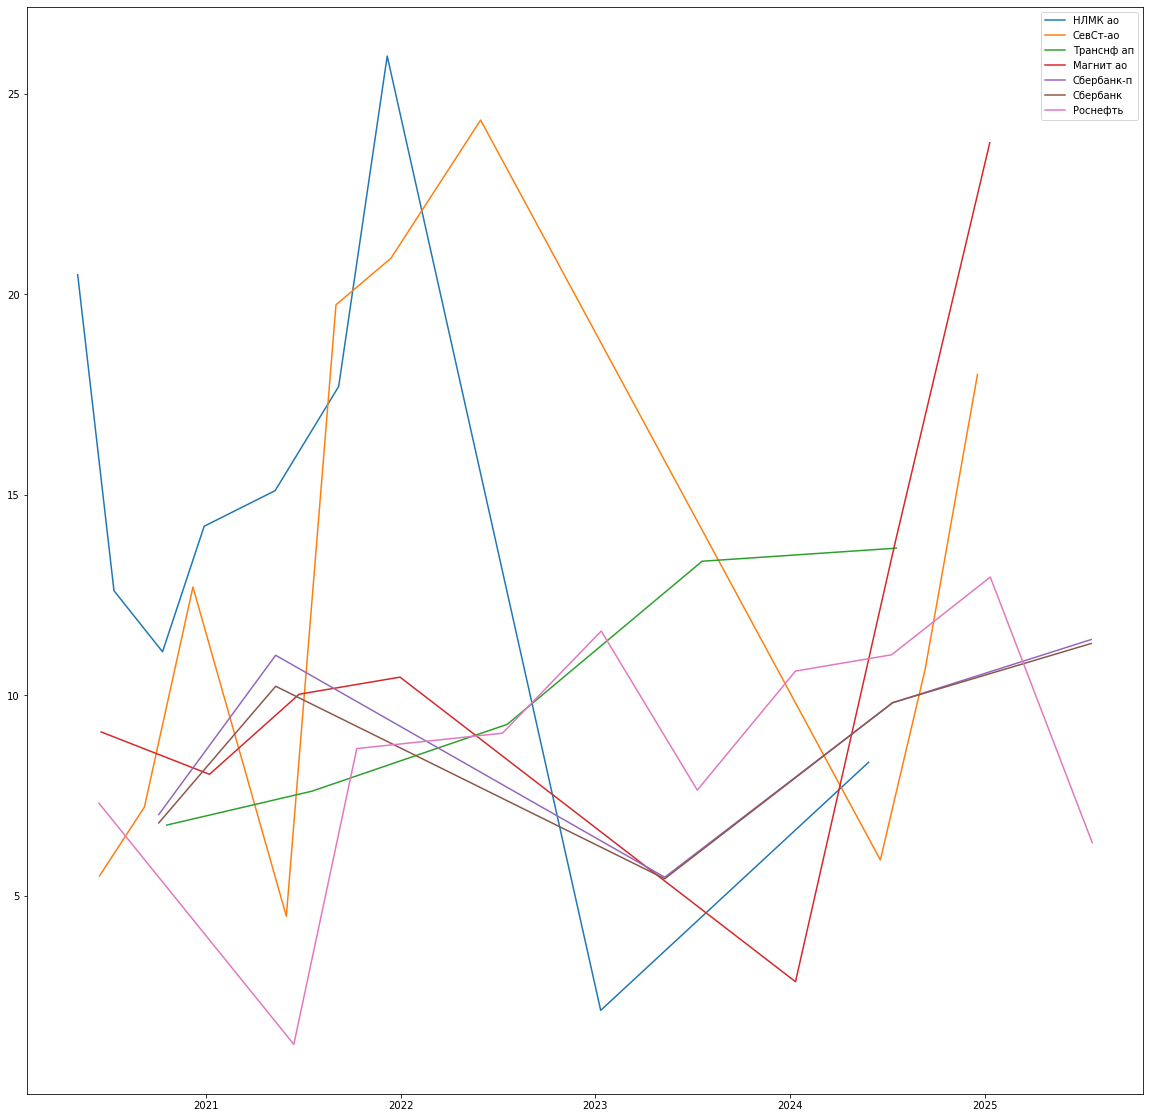

In [87]:
draw_graphs(graphs, 7, 14)

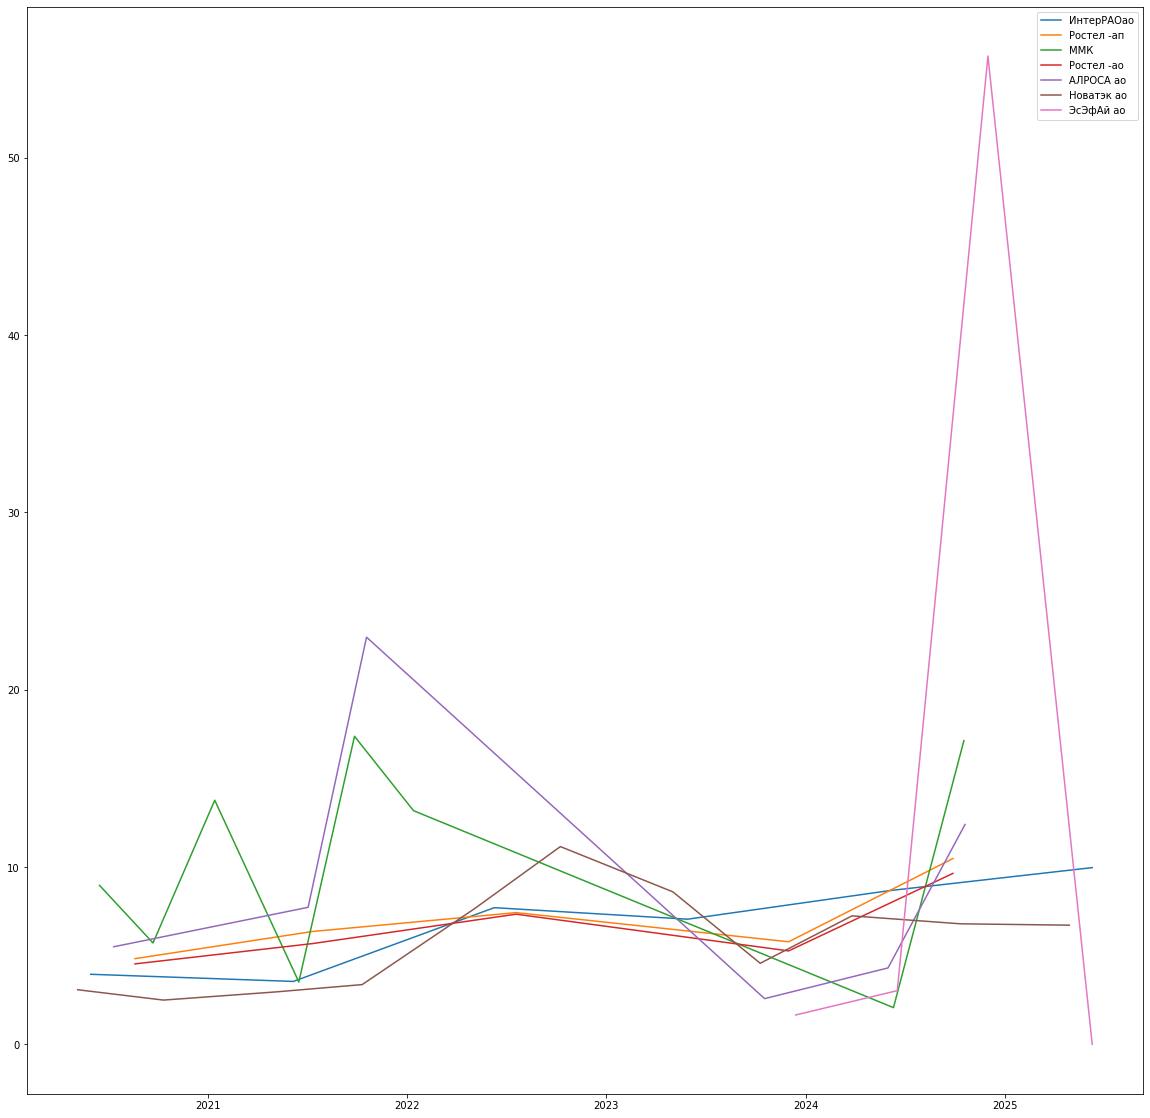

In [88]:
draw_graphs(graphs, 14, 21)

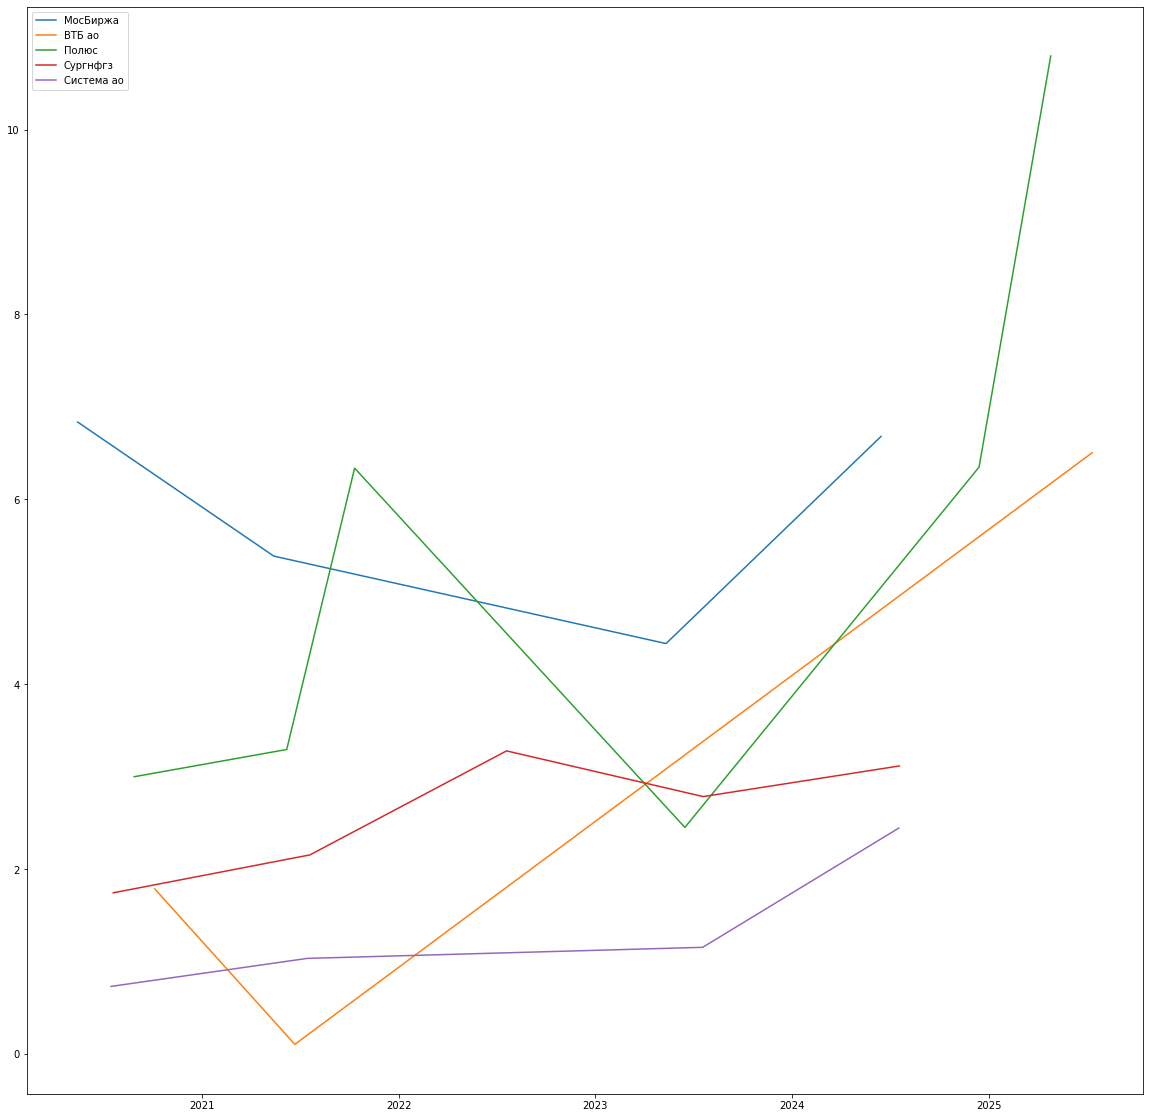

In [89]:
draw_graphs(graphs, 21, 28)